In [1]:
from scipy.stats import qmc
import pandas as pd

import numpy as np
import pyccl as ccl
# --- halo‑model pieces ---
from pyccl.halos.massdef import MassDef200m
from pyccl.halos.hmfunc.tinker10 import MassFuncTinker10
from pyccl.halos.hbias.tinker10 import HaloBiasTinker10
from pyccl.halos.concentration.duffy08 import ConcentrationDuffy08
from pyccl.halos.profiles.nfw import HaloProfileNFW
from pyccl.halos.halo_model import HMCalculator
from pyccl.halos.pk_4pt import halomod_Tk3D_cNG   # full (1h+2h+3h+4h) trispectrum
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


In [2]:
cosmotable = np.loadtxt('CosmoTable.dat')
cosmotable_om = cosmotable[:,1]
cosmotable_h = cosmotable[:,2]
cosmotable_w0 = cosmotable[:,3]
cosmotable_sig8 =  cosmotable[:,4]
cosmotable_oc = cosmotable[:,5]

# Define parameter bounds based on min and max values
param_bounds = np.array([
    [np.min(cosmotable_om), cosmotable_om.max()],
    [cosmotable_h.min(), cosmotable_h.max()],
    [cosmotable_w0.min(), cosmotable_w0.max()],
    [cosmotable_sig8.min(), cosmotable_sig8.max()],
    [cosmotable_oc.min(), cosmotable_oc.max()]
])

print(param_bounds)
# Number of samples (adjust as needed)
num_samples = 100

# Generate Latin Hypercube Samples
sampler = qmc.LatinHypercube(d=param_bounds.shape[0])
lh_samples = sampler.random(n=num_samples)

# Scale samples to the parameter bounds
lh_scaled = qmc.scale(lh_samples, param_bounds[:, 0], param_bounds[:, 1])

# Convert to a structured array or DataFrame if needed

lh_df = pd.DataFrame(cosmotable[:,1:], columns=["Om", "h", "w0", "sig8", "Oc"])

# Display or save results
# print(lh_df)  # Print first few samples

# cosmotable
# lh_df


[[ 0.1019  0.5482]
 [ 0.6034  0.8129]
 [-1.9866 -0.5223]
 [ 0.4716  1.3428]
 [ 0.0546  0.5009]]


In [3]:
nz_file = "/feynman/work/dap/lcs/vt272285/LDT_2cell_l1_norm copy/nz_arrays_bin5.npy" 
nz_array = np.load(nz_file)
nz_array = nz_array.T

nz_spline = interp1d(nz_array[0], nz_array[1], kind='cubic', bounds_error=False, fill_value=0)
newz = np.linspace(nz_array[0][0], nz_array[0][-1], 5)
newnz = nz_spline(newz)

# plt.plot(nz_array[0], nz_array[1])
# plt.plot(newz, newnz)

# Total Covariance of the Matter Power Spectrum

This section explains the logic of the function `compute_total_covariance`, which estimates the full covariance matrix of the matter power spectrum $P(k)$ by including:

1. **Gaussian covariance**: cosmic variance and shot noise
2. **Non-Gaussian covariance**: from the connected trispectrum
3. **Super-sample covariance (SSC)**: due to large-scale density modes that modulate small-scale power

---

We aim to compute:

$$
\mathrm{Cov}(k_i, k_j) = \langle \Delta P(k_i) \Delta P(k_j) \rangle
$$

with three contributions:

- $\mathrm{Cov}_{\mathrm{Gauss}}$: Diagonal cosmic variance and shot noise
- $\mathrm{Cov}_{\mathrm{NG}}$: Trispectrum-induced mode coupling
- $\mathrm{Cov}_{\mathrm{SSC}}$: Super-sample covariance due to background density modes

The trispectrum is the connected 4-point correlation function in Fourier space.

It is the next-order statistic after the bispectrum (3-point).

While the power spectrum tells you how much fluctuation exists on a given scale, the trispectrum tells you about how the fluctuations on different scales are correlated with each other in a more complex way.

In the Gaussian limit (linear regime), the covariance is diagonal and given by:
But in the non-linear regime, due to mode coupling from gravitational evolution, the covariance becomes non-Gaussian and non-diagonal.

This is where the trispectrum $T(k, -k, k', -k')$ enters.


Super-sample covariance arises from modes larger than the survey window—modes you cannot observe directly because they’re larger than your survey volume, but they still affect the smaller scales within your survey.

These long-wavelength modes change the mean density or curvature inside the observed volume, essentially shifting the background on which your fluctuations evolve.

So, $C = C_G + C_{NG} + C_{SSC}$


---

In [4]:

def compute_total_covariance(tk3d, k, a, pk_mean, volume, delta_A0=1.,
                            response=None, sigma_b_squared=None):
    """
    Compute total covariance matrix: Gaussian + non-Gaussian (trispectrum) + SSC.

    Parameters
    ----------
    cosmo : pyccl.Cosmology
    tk3d : pyccl.Tk3D
    k : array_like
        Wavenumbers [h/Mpc]
    a : float
        Scale factor
    pk_mean : array_like
        Mean P(k, a)
    volume : float
        Effective survey volume [Mpc^3/h^3]
    delta_A0 : float
        Optional shot noise component
    response : array_like or None
        dlnP/dδb response function. If None, uses dlnP/dlnk as approximation.
    sigma_b_squared : float or None
        Variance of background mode (from survey window function).

    Returns
    -------
    cov_total : 2D ndarray
        Full covariance matrix with SSC.
    """
    # 1. Gaussian
    delta_k = np.gradient(k)
    Nk = (volume * k**2 * delta_k) / (2 * np.pi**2)
    sigma2 = (2 / Nk) + delta_A0**2
    cov_gauss = np.diag(sigma2 * pk_mean**2)

    # 2. Non-Gaussian
    Tmat = tk3d(k, a)
    cov_ng = 0.5 * (Tmat + Tmat.T) / volume #/ volume

    # 3. Super-sample covariance
    if response is None:
        # Default: dlnP/dlnk
        dlnk = np.gradient(np.log(k))
        dlnP = np.gradient(np.log(pk_mean))
        slope = dlnP / dlnk
        response = 68.0 / 21.0 - (1.0 / 3.0) * slope

    if sigma_b_squared is None:
        # Default: estimate from top-hat window (approx)
        R_survey = (3 * volume / (4 * np.pi))**(1/3)
        k_window = np.linspace(1e-5, 1e1, 100)
        W = 3 * (np.sin(k_window * R_survey) - k_window * R_survey * np.cos(k_window * R_survey)) / (k_window * R_survey)**3
        pk_window = np.interp(k_window, k, pk_mean)
        integrand = k_window**2 * pk_window * W**2
        sigma_b_squared = np.trapz(integrand, k_window) / (2 * np.pi**2)

    cov_ssc = np.outer(response, response) * pk_mean[:, None] * pk_mean[None, :] * sigma_b_squared #/ (volume**2)

    # Total covariance
    cov_total = cov_gauss + cov_ng + (0.95 *cov_ssc)
    # cov_to0al = cov_ssc
    # plt.figure()
    # plt.imshow(cov_total)
    # plt.colorbar()
    # plt.show() 
    return cov_total


In [5]:
# cosmo_index_to_run = 18
def fourier_coordinate(x, y, map_size):
    return (((map_size // 2 )+ 1) * x) + y

import jax
import jax.numpy as jnp
from jax.numpy.fft import rfft2
def calculate_Cls_(map, angle, ell_min, ell_max, n_bins):
    """
    map: the image from which the angular power spectra (Cls) has to be calculated
    angle: side angle in the units of degree
    ell_min: the minimum multipole moment to get the Cls
    ell_max: the maximum multipole moment to get the Cls
    n_bins: number of bins in the ells
    """
    angle = jnp.array(angle)
    ell_min = jnp.array(ell_min)
    ell_max = jnp.array(ell_max)
    n_bins = jnp.array(n_bins, int)

    # Calculate the Fourier Transforms
    map_ft = rfft2(map) ## rfft2
    map_ft = map_ft.flatten()
    ell_edges = jnp.linspace(ell_min, ell_max, num=n_bins+1)

    # Define pixel physical size in Fourier space
    lpix = 360/angle 
    # Initialize arrays to store power and hits for each ell bin
    power_l = jnp.zeros(n_bins)
    hits = jnp.zeros(n_bins)
    
    def loop_body(j, val):
        i, power_l, hits = val
        lx = jnp.minimum(i, map.shape[1] - i) * lpix
        ly = j * lpix
        l = jnp.sqrt(lx**2. + ly**2.)
        pixid = fourier_coordinate(i, j, map.shape[0])
        bin_idx = jnp.digitize(l, ell_edges) #- 1
        power_l = power_l.at[bin_idx].add(jnp.abs(map_ft[pixid]**2.))
        hits = hits.at[bin_idx].add(1)
        return i, power_l, hits

    def outer_loop_body(i, val):
        _, power_l, hits = val
        _, power_l, hits = jax.lax.fori_loop(0, map.shape[0], loop_body, (i, power_l, hits))
        return i, power_l, hits

    _, power_l, hits = jax.lax.fori_loop(0, map.shape[1], outer_loop_body, (0, power_l, hits))

    # Calculate Cls based on the accumulated power and hits
    cls_values = jnp.where(hits > 0, power_l / hits, 0.0)  # Ensure no division by zero
    cls_values = jnp.maximum(cls_values, 0)  # Clip negative values to zero if any
    ell_bins = 0.5 * (ell_edges[1:] + ell_edges[:-1])
    normalization = (angle * np.pi / 180. /(map.shape[0] * map.shape[0]))**2.
    return jnp.array(ell_edges), jnp.array(ell_bins), jnp.array(cls_values * normalization)


In [6]:

def compute_total_covariance(tk3d, k, a, pk_mean, volume, delta_A0=.05,
                            response=None, sigma_b_squared=None):
    """
    Compute total covariance matrix: Gaussian + non-Gaussian (trispectrum) + SSC.

    Parameters
    ----------
    cosmo : pyccl.Cosmology
    tk3d : pyccl.Tk3D
    k : array_like
        Wavenumbers [h/Mpc]
    a : float
        Scale factor
    pk_mean : array_like
        Mean P(k, a)
    volume : float
        Effective survey volume [Mpc^3/h^3]
    delta_A0 : float
        Optional shot noise component
    response : array_like or None
        dlnP/dδb response function. If None, uses dlnP/dlnk as approximation.
    sigma_b_squared : float or None
        Variance of background mode (from survey window function).

    Returns
    -------
    cov_total : 2D ndarray
        Full covariance matrix with SSC.
    """
    # 1. Gaussian
    delta_k = np.diff(k, append=2*k[-1] - k[-2])

    Nk = (volume * k**2 * delta_k) / (2 * np.pi**2)
    sigma2 = (2 / Nk) + delta_A0**2
    cov_gauss = np.diag(sigma2 * pk_mean**2)

    # 2. Non-Gaussian
    Tmat = tk3d(k, a)
    # Tmat = np.array([[tk3d(ki, kj, a) for kj in k] for ki in k])

    cov_ng = 0.5 * (Tmat + Tmat.T) / volume / volume

    # 3. Super-sample covariance
    if response is None:
        # Default: dlnP/dlnk
        dlnk = np.gradient(np.log(k))
        dlnP = np.gradient(np.log(pk_mean))
        slope = dlnP / dlnk
        response = 68.0 / 21.0 - (1.0 / 3.0) * slope

    if sigma_b_squared is None:
        # Default: estimate from top-hat window (approx)
        R_survey = (3 * volume / (4 * np.pi))**(1/3)
        k_window = np.linspace(1e-4, 10, 100)
        W = 3 * (np.sin(k_window * R_survey) - k_window * R_survey * np.cos(k_window * R_survey)) / (k_window * R_survey)**3
        pk_window = np.interp(k_window, k, pk_mean)
        # integrand = k_window**2 * pk_window * W**2
        integrand = k_window**2 * pk_window * W**2 / (2 * np.pi**2)

        sigma_b_squared = np.trapz(integrand, k_window) / (2 * np.pi**2)

    cov_ssc = np.outer(response, response) * pk_mean[:, None] * pk_mean[None, :] * sigma_b_squared / (volume**2)

    # Total covariance
    cov_total = cov_gauss + 1.*cov_ng + (1.*cov_ssc)
    # plt.figure()
    # plt.imshow(cov_total)
    # plt.colorbar()
    # plt.show() 
    return cov_total 

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


H: [ 71.04        65.95552736  93.5429087  133.61189123 180.63634562]
Effective volume = 1.16e+10 (Mpc/h)^3
h: 0.7104, Oc: 0.0546, Ob: 0.0473, Om: 0.1019, sig8: 1.3428, w0: -1.6154, wa: 0


/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/pk2d.py:285: RuntimeWarning: divide by zero encountered in log
  lk_use = np.log(k_use)
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1021: RuntimeWarning: divide by zero encountered in divide
  f2 = 5./7. - 0.5 * (1 + kk ** 2 / kr2) * (1 + kp / kk * cth) + \
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1021: RuntimeWarning: invalid value encountered in multiply
  f2 = 5./7. - 0.5 * (1 + kk ** 2 / kr2) * (1 + kp / kk * cth) + \
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1022: RuntimeWarning: divide by zero encountered in divide
  2/7. * kk ** 2 / kr2 * (1 + kp / kk * cth)**2
/feynman/home/dap/lcs/vt272285/.conda/envs/general/lib/python3.8/site-packages/pyccl/halos/pk_4pt.py:1022: RuntimeWarning: invalid value encountered in multiply
  2

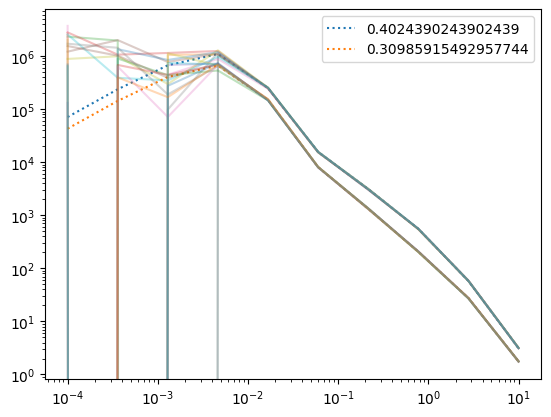

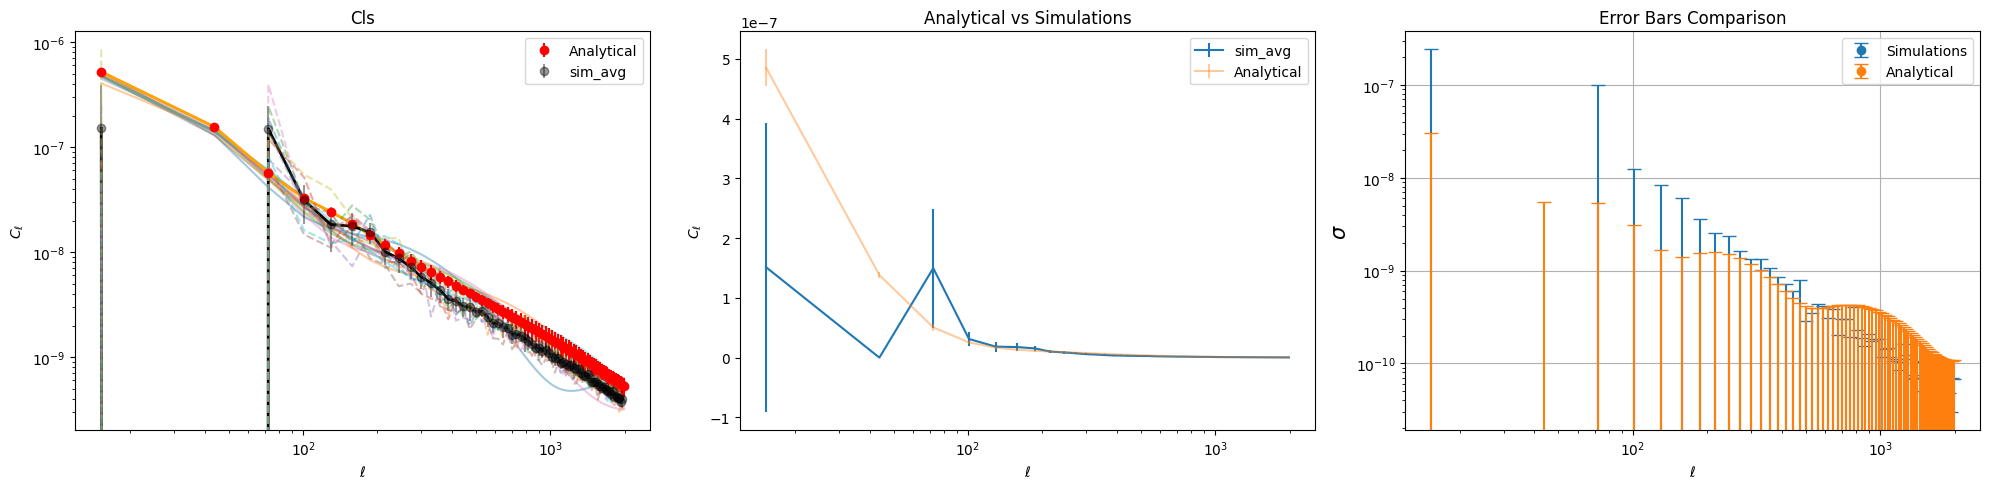

In [7]:
# ------------------------
# Define redshift distribution
# ------------------------
z_nz = newz #nz_array[0] #np.linspace(0.01, 2., 10)  # sampling of redshifts
a_nz = 1 / (1 + z_nz)
k = np.logspace(-4, 1, 10)         #Mpc^-1
# k = np.linspace(1e-3, 4., 100)

n_real = 10

cosmo_index_to_run = 1

Cl_sim = []
for i in range(1, 11): # Loop over 10 simulation realizations
    los_cone_filename = f'GalCatalog_LOS_cone{i}_bin5.npy'
    if cosmo_index_to_run < 10:
        map_path = f'/feynman/work/dap/lcs/share/at/mass_maps/0{cosmo_index_to_run}_a/{los_cone_filename}'
    else:
        map_path = f'/feynman/work/dap/lcs/share/at/mass_maps/{cosmo_index_to_run}_a/{los_cone_filename}'
    
    # try:
    # print(f"  Loading map: {map_path}") # Optional: for debugging
    mass_map_data = np.load(map_path)
    # ell, Cl = compute_Cl_flat_sky(mass_map_data, theta_pix_rad)
    edges, bins, Cl = calculate_Cls_(jnp.array(mass_map_data), 10, 1, 2e3, 70)
    # bins_sim.append(bins)
    Cl_sim.append(Cl)
Cl_sim = np.array(Cl_sim)
Cl_sim_avg = np.average(Cl_sim, axis=0)

# plt.figure()
# plt.loglog(bins, Cl_sim_avg, ls='-', lw=2, c='r')
# plt.loglog(bins, Cl_sim.T, alpha=0.3)
# plt.show()

# ------------------------
# Define cosmology
# ------------------------
h = lh_df['h'][cosmo_index_to_run]
Oc = lh_df['Oc'][cosmo_index_to_run]
Om = lh_df['Om'][cosmo_index_to_run]
sig8 = lh_df['sig8'][cosmo_index_to_run]
w0 = lh_df['w0'][cosmo_index_to_run]
wa = 0 # Assuming wa=0 based on original code
Ob = Om - Oc # Calculate Ob consistently
# Other fixed parameters from original code
H0 = 100.0 * h # H0 in km/s/Mpc
ns = 0.963
mnu = 0.0

# Speed of light
c = 299792.458  # km/s

# Sky area in steradians
sky_area_deg2 = 100
sky_area_sr = sky_area_deg2 * (4 * np.pi) / 41253

# If not already normalized
norm = np.trapz(newnz, newz)
newnz /= norm

cosmo = ccl.Cosmology(Omega_c=Oc, Omega_b=Ob, h=h,
                      n_s=ns, sigma8=sig8,w0=w0,wa=wa)


# Compute comoving distance and H(z)
chi = ccl.comoving_radial_distance(cosmo, a_nz)
H = ccl.h_over_h0(cosmo, a_nz) * cosmo['h'] * 100  # in km/s/Mpc

# Volume element weighted by n(z)
dV_dz = sky_area_sr * newnz * chi**2 * c / H

# Effective volume
V_eff = np.trapz(dV_dz, newz) / (h**3)

print(f"H: {H}")
print(f"Effective volume = {V_eff:.2e} (Mpc/h)^3")
print(f"h: {h}, Oc: {Oc}, Ob: {Ob}, Om: {Om}, sig8: {sig8}, w0: {w0}, wa: {wa}")
# -------------------------------------------------
# 2. halo‑model ingredients & trispectrum
# -------------------------------------------------
mdef   = MassDef200m
mf    = MassFuncTinker10(mass_def=mdef)
hbias = HaloBiasTinker10(mass_def=mdef)
conc  = ConcentrationDuffy08(mass_def=mdef)

profile = HaloProfileNFW(mass_def=mdef, concentration=conc) 
hmc     = HMCalculator(mass_function=mf,halo_bias=hbias)

# ------------------------
# Storage for all redshifts
# ------------------------
P_means_all = []
P_samples_all = []

# ------------------------
# Loop over redshift samples
# ------------------------
for a in a_nz:
    P_mean = ccl.power.nonlin_matter_power(cosmo, k, a)
    tk3d = halomod_Tk3D_cNG(cosmo, hmc, profile,
                            lk_arr=k, a_arr=np.array([a]),
                            use_log=False)
    Tmat = tk3d(k, a)

    cov_total = compute_total_covariance(tk3d, k, a, P_mean, V_eff, delta_A0=.01)

    eigvals, eigvecs = np.linalg.eigh(cov_total)
    eigvals = np.clip(eigvals, 0, None)
    L = eigvecs @ np.diag(np.sqrt(eigvals))

    
    P_samples = P_mean[:, None] + L @ np.random.randn(len(k), n_real)

    P_means_all.append(P_mean)
    P_samples_all.append(P_samples)

P_means_all = np.array(P_means_all)        
P_samples_all = np.array(P_samples_all)   

plt.figure()

for ind in range(2):
    plt.loglog(k, P_means_all[ind+2], ls=":", label=a_nz[ind+2])
    plt.loglog(k, P_samples_all[ind+2], alpha=0.3)
    
plt.legend()

sort_idx = np.argsort(a_nz)

# Step 2: Sort all arrays
a_nz_sorted = a_nz[sort_idx]
P_means_sorted = P_means_all[sort_idx]
P_samples_sorted = P_samples_all[sort_idx]

# Create Pk2D for the mean
pk2d_mean = ccl.Pk2D(
    a_arr=a_nz_sorted,
    lk_arr=np.log(k),
    pk_arr=P_means_sorted,
    is_logp=False,
    extrap_order_lok=1,
    extrap_order_hik=1
)

# Create Pk2D for each realization
pk2d_samples = []

for r in range(n_real):
    pk_arr_r = P_samples_sorted[:, :, r]  # shape (n_z, n_k)
    pk2d_r = ccl.Pk2D(
        a_arr=a_nz_sorted,
        lk_arr=np.log(k),
        pk_arr=pk_arr_r,
        is_logp=False,
        extrap_order_lok=1,
        extrap_order_hik=1
    )
    pk2d_samples.append(pk2d_r)
    
nz = newnz 
tracer = ccl.WeakLensingTracer(cosmo, dndz=(z_nz, nz))
ell = bins #np.arange(50, 2000,100)
cls = ccl.angular_cl(cosmo, tracer, tracer, ell)

cl_mean = ccl.angular_cl(cosmo, tracer, tracer, ell, p_of_k_a=pk2d_mean)
cls_realizations = []

for pk2d_r in pk2d_samples:
    cl = ccl.angular_cl(cosmo, tracer, tracer, ell, p_of_k_a=pk2d_r)
    cls_realizations.append(cl)

cls_realizations = np.array(cls_realizations) 

def apply_pixel_window(ells, theta_deg=10.0, npix=1200):
    """
    Apply pixel window function to theoretical Cls.

    Parameters:
    - cls: array of C_ell values (same length as ells)
    - ells: array of multipoles (ell values)
    - theta_deg: total angular size of the map (in degrees)
    - npix: number of pixels on one side of the square map

    Returns:
    - cls_smoothed: Cls multiplied by the pixel window function
    """
    # Convert pixel size to radians
    theta_pix_rad = np.deg2rad(theta_deg / npix)

    # Pixel window function W(ell) = sinc(ell * theta_pix / 2)^2
    # np.sinc(x) = sin(pi*x)/(pi*x), so we must divide by pi
    arg = ells * theta_pix_rad / 2
    W_ell = np.sinc(arg / np.pi)**2

    return W_ell

win_func = apply_pixel_window(ell, 10, 1200)

plt.figure(figsize=(20,5))
plt.subplot(131)
plt.plot(ell,  (cls_realizations * win_func).T, alpha=0.4)
# plt.plot(ell, cl_mean * win_func, ls="-", c='b', label='pyccl')
plt.plot(ell, cls * win_func, ls="-", c='r')
plt.errorbar(ell, cls * win_func, yerr=np.sqrt(np.var(cls_realizations * win_func,axis=0)) , fmt='o', c='r', label='Analytical')
plt.plot(ell,cls, lw=2,c='orange')
factor = h**0
plt.loglog(bins[:-1], Cl_sim_avg[:-1]*factor, ls='-', lw=2, c='k')
plt.errorbar(bins[:-1], Cl_sim_avg[:-1]*factor, yerr=np.sqrt(np.var(Cl_sim*factor,axis=0))[:-1], fmt='o', c='k', label='sim_avg',alpha=0.4)
plt.loglog(bins[:-1], Cl_sim.T[:-1]*factor, alpha=0.4, ls="--")
plt.legend()
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$')
# plt.xscale('log')
plt.yscale('log')
plt.title('Cls')

plt.subplot(132)
plt.errorbar(bins, Cl_sim_avg*factor, yerr=np.sqrt(np.var(Cl_sim*factor,axis=0)), fmt= '' ,label="sim_avg")
plt.errorbar(ell, cl_mean * win_func, yerr=np.sqrt(np.var(cls_realizations * win_func,axis=0)),fmt='', label="Analytical", alpha=0.4)
plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.title('Analytical vs Simulations')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$') 

plt.subplot(133)
std1 = np.sqrt(np.var(Cl_sim*factor,axis=0))
std2 = np.sqrt(np.var(cls_realizations * win_func,axis=0))
plt.errorbar(bins, np.zeros_like(std1), yerr=std1, fmt='o', capsize=5, label='Simulations')
plt.errorbar(ell, np.zeros_like(std2), yerr=std2, fmt='o', capsize=5, label='Analytical')  
# plt.xticks(bins, labels)
plt.title('Error Bars Comparison')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\sigma$',size=15)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


(10, 70) (10, 70)


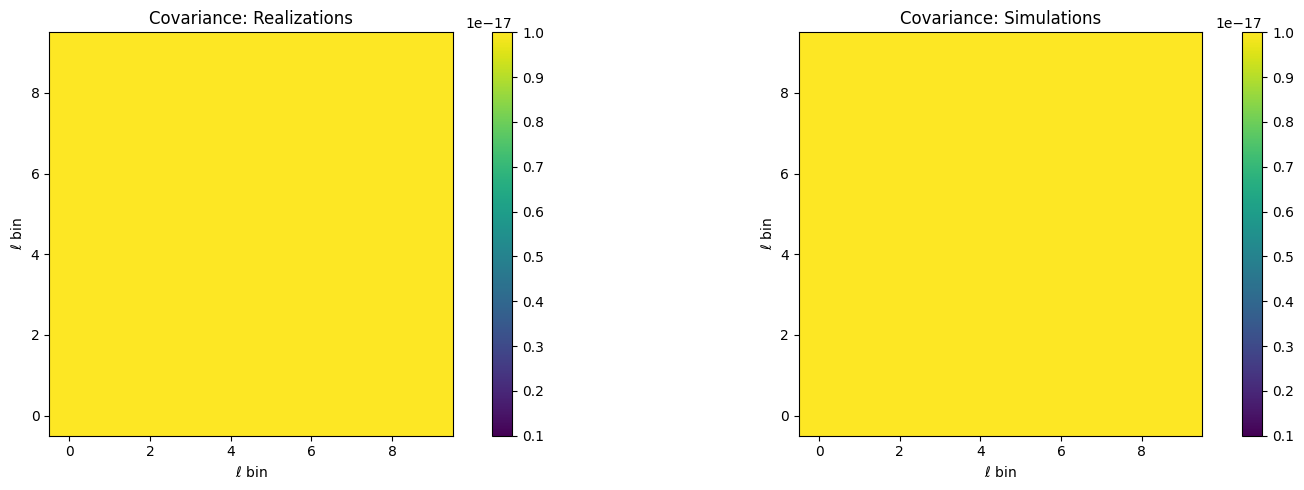

In [8]:

def compare_covariances_different_ells(cls_realizations, ell, Cl_sim, bins, show_diff=False):
    """
    Compare covariance matrices from two sets of C_ell realizations on different ℓ grids.

    Parameters
    ----------
    cls_realizations : ndarray
        Shape (m1, n_realizations) for ℓ = ell
    ell : ndarray
        ℓ-bin centers for cls_realizations
    Cl_sim : ndarray
        Shape (m2, n_realizations) for ℓ = bins
    bins : ndarray
        ℓ-bin centers for Cl_sim
    show_diff : bool
        Whether to plot difference of covariances

    Returns
    -------
    cov1, cov2, cov_diff (if show_diff)
    """
    # Transpose to shape (n_realizations, m_ell)
    cls_realizations_ = cls_realizations
    Cl_sim_ = Cl_sim

    # Interpolate Cl_sim to match ell
    n_realizations = Cl_sim_.shape[0]
    print(cls_realizations_.shape, Cl_sim_.shape)
    Cl_sim_interp = np.zeros_like(cls_realizations_)

    for i in range(n_realizations):
        # print(bins.shape, Cl_sim_[i].shape)
        f = interp1d(bins, Cl_sim_[i], kind='linear', bounds_error=False, fill_value='extrapolate')
        Cl_sim_interp[i] = f(ell)

    # Compute covariance matrices
    cov1 = np.cov(cls_realizations_, rowvar=True)
    cov2 = np.cov(Cl_sim_, rowvar=True)
    cov_diff = cov1 - cov2

    # Plotting
    fig, axs = plt.subplots(1, 3 if show_diff else 2, figsize=(16, 5))
    # cov1 = np.log(cov1+1e-20)
    # cov2 = np.log(cov2+1e-20)
    vmin = 1e-18
    vmax= 1e-17
    im0 = axs[0].imshow(cov1, origin='lower', cmap='viridis',vmin=vmin,vmax=vmax)
    axs[0].set_title("Covariance: Realizations")
    fig.colorbar(im0, ax=axs[0], fraction=0.046)

    im1 = axs[1].imshow(cov2, origin='lower', cmap='viridis',vmin=vmin,vmax=vmax)
    axs[1].set_title("Covariance: Simulations")
    fig.colorbar(im1, ax=axs[1], fraction=0.046)

    if show_diff:
        v = np.max(np.abs(cov_diff))
        im2 = axs[2].imshow(cov_diff, origin='lower', cmap='bwr', vmin=-v, vmax=v)
        axs[2].set_title("Covariance Difference")
        fig.colorbar(im2, ax=axs[2], fraction=0.046)

    for ax in axs:
        ax.set_xlabel(r'$\ell$ bin')
        ax.set_ylabel(r'$\ell$ bin')

    plt.tight_layout()
    plt.show()

    return cov1, cov2, cov_diff if show_diff else None

cov1, cov2, cov_diff = compare_covariances_different_ells(cls_realizations, ell, Cl_sim*factor, bins*h)
